In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [113]:
df=pd.read_csv(r"C:\Users\TAIWO\Desktop\Malaria Dataset\malaria_patient_data.csv")

In [114]:
df

,patient_id,age,state,season,mosquito_net,owns_tv,random_text
0,1000,9,G0mbe,NaN,N,Yes,123
1,1001,25,Ogun,Dry,YES,Yes,NaN
2,1002,68,Anambra,rainy,NaN,No,abc
3,1003,NaN,Abuja,NaN,N,NaN,123
4,1004,49,Plateau,R@iny,YES,Yes,abc
...,...,...,...,...,...,...,...
4495,5495,40,Imo,Rainy,No,No,abc
4496,5496,68,Delta,Rainy,YES,NaN,123
4497,5497,51,Ekiti,R@iny,no,No,NaN
4498,5498,54,Kaduna,dry,no,No,abc


In [49]:
# First five rolls
df.head()

,patient_id,age,state,season,mosquito_net,owns_tv,random_text
0,1000,9,G0mbe,NaN,N,Yes,123
1,1001,25,Ogun,Dry,YES,Yes,NaN
2,1002,68,Anambra,rainy,NaN,No,abc
3,1003,NaN,Abuja,NaN,N,NaN,123
4,1004,49,Plateau,R@iny,YES,Yes,abc


In [50]:
#info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    4500 non-null   int64 
 1   age           4453 non-null   object
 2   state         4500 non-null   object
 3   season        3728 non-null   object
 4   mosquito_net  3850 non-null   object
 5   owns_tv       3063 non-null   object
 6   random_text   3358 non-null   object
dtypes: int64(1), object(6)
memory usage: 246.2+ KB


In [51]:
# null values
df.isnull().sum()

patient_id         0
age               47
state              0
season           772
mosquito_net     650
owns_tv         1437
random_text     1142
dtype: int64

In [52]:
#Dataset Columns
df.columns

Index(['patient_id', 'age', 'state', 'season', 'mosquito_net', 'owns_tv',
       'random_text'],
      dtype='object')

In [53]:
# Datatypes of each column
df.dtypes

patient_id       int64
age             object
state           object
season          object
mosquito_net    object
owns_tv         object
random_text     object
dtype: object

In [54]:
# Unique values of States
df["state"].unique()

array(['G0mbe', 'Ogun', 'Anambra', 'Abuja', 'Plateau', 'Niger', 'Ondo',
       'Oyo', 'gombe', 'Zamfara', 'Delta', 'Kaduna', 'Nasarawa', 'Enugu',
       'Cross River', 'Borno', 'kogi', 'lagos ', 'Adamawa', 'crossriver',
       'Kwara', 'Benue', 'Ed0o', 'Rivers', 'Abla', 'Bauchi', 'S0koto',
       'Ekiti', 'Imo', 'benue', 'Kano', 'Lagos', 'Kaduba', 'katsina',
       'Bayelsa', 'Taraba', 'Jigawa', 'KAN0', 'Ebonyi', 'Yobe', 'Kebbis',
       '??Rivers', 'Osun'], dtype=object)

In [55]:
df["state"].nunique()

43

In [56]:
# Unique values of Seasons
df["season"].unique()

array([nan, 'Dry', 'rainy', 'R@iny', 'Rainy', 'dry'], dtype=object)

In [57]:
# Unique values of mosquito net
df["mosquito_net"].unique()

array(['N', 'YES', nan, 'Y', 'no', 'No', 'Yes'], dtype=object)

In [58]:
# unique values of owns tv
df["owns_tv"].unique()

array(['Yes', 'No', nan], dtype=object)

In [59]:
## unique values of random text
df["random_text"].unique()

array(['123', nan, 'abc', '@@@'], dtype=object)

In [60]:
#Value counts of seasons
df["season"].value_counts()

season
rainy    760
R@iny    759
Rainy    759
Dry      727
dry      723
Name: count, dtype: int64

In [61]:
#Value counts of mosquito net
df["mosquito_net"].value_counts()

mosquito_net
N      665
Yes    655
no     653
Y      651
YES    617
No     609
Name: count, dtype: int64

In [62]:
#Value counts of owns tv
df["owns_tv"].value_counts()

owns_tv
Yes    1597
No     1466
Name: count, dtype: int64

#ASSIGNMENT

1.Missing values

 After doing df.isnull( ).sum( ),we found out that these columns are missing:
  1. age
  2. season    
  3. mosquito_net
  4. owns_tv
  5. random_text

2.Inconsistent Naming convention

There are inconsistent naming in the State Names on the state columns:
for examples:
    
 "G0mbe"<br>
 "gombe"<br>
 "Kaduba"<br>
 "S0koto"<br>
 "KAN0"<br>
 "Kebbis"<br>
 "??Rivers"<br>
 "Abla"<br>
 "crossriver"<br>
 "Ed0o"<br>
 "benue"    

3.Inconsistent labels

Examples<br>:
 rainy<br>
 R@iny<br>
 Dry

After Standardization:

 Rainy<br>
 Dry   

3.Irrelevant column


random_text which contains:

 "123"<br>
 "abc"<br>
 "@@@"<br>
This columns is useless so it should be removed.

5. Data Type issues

The data type issues involved in the age column is that some rows are empty i.e null values,where as the column should be numeric.<br>
categorical_columns should be standardized. 

In [63]:
df.drop(columns =["random_text"], inplace=True)

In [64]:
df.head()

,patient_id,age,state,season,mosquito_net,owns_tv
0,1000,9,G0mbe,NaN,N,Yes
1,1001,25,Ogun,Dry,YES,Yes
2,1002,68,Anambra,rainy,NaN,No
3,1003,NaN,Abuja,NaN,N,NaN
4,1004,49,Plateau,R@iny,YES,Yes


In [88]:
#7. Standardizing State names in the  column "state"
df["state"]=df["state"].replace({
    "G0mbe":"Gombe",
    "gombe":"Gombe",
    "Kaduba":"Kaduna",
    "S0koto":"Sokoto",
    "KANO":"Kano",
    "KAN0":"Kano",
    "Kebbis":"Kebbi",
    "??Rivers":"Rivers",
    "Abla":"Abia",
    "crossriver":"Cross River",
    "Crossriver":"Cross River",
    "Ed0o":"Edo",
    "benue":"Benue",
    "lagos":"Lagos",
    "lagos ":"Lagos",
    "kogi":"Kogi",
    "katsina":"Katsina",
})

In [86]:
afstd_1=df["state"].unique()
afstd_2=df["state"].unique()
print("We now have eac state name standardized as below:",afstd_1,"and the total number of states is :", afstd_2)

We now have eac state name standardized as below: ['G0mbe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'gombe'
 'Zamfara' 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno'
 'kogi' 'lagos ' 'Adamawa' 'crossriver' 'Kwara' 'Benue' 'Ed0o' 'Rivers'
 'Abla' 'Bauchi' 'S0koto' 'Ekiti' 'Imo' 'benue' 'Kano' 'Lagos' 'Kaduba'
 'katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'KAN0' 'Ebonyi' 'Yobe' 'Kebbis'
 '??Rivers' 'Osun'] and the total number of states is : ['G0mbe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'gombe'
 'Zamfara' 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno'
 'kogi' 'lagos ' 'Adamawa' 'crossriver' 'Kwara' 'Benue' 'Ed0o' 'Rivers'
 'Abla' 'Bauchi' 'S0koto' 'Ekiti' 'Imo' 'benue' 'Kano' 'Lagos' 'Kaduba'
 'katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'KAN0' 'Ebonyi' 'Yobe' 'Kebbis'
 '??Rivers' 'Osun']


In [87]:
afstd_1=df["state"].unique()
afstd_2=df["state"].unique()
print("We now have eac state name standardized as below:",afstd_1,"and the total number of states is :", afstd_2)

We now have eac state name standardized as below: ['G0mbe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'gombe'
 'Zamfara' 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno'
 'kogi' 'lagos ' 'Adamawa' 'crossriver' 'Kwara' 'Benue' 'Ed0o' 'Rivers'
 'Abla' 'Bauchi' 'S0koto' 'Ekiti' 'Imo' 'benue' 'Kano' 'Lagos' 'Kaduba'
 'katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'KAN0' 'Ebonyi' 'Yobe' 'Kebbis'
 '??Rivers' 'Osun'] and the total number of states is : ['G0mbe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'gombe'
 'Zamfara' 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno'
 'kogi' 'lagos ' 'Adamawa' 'crossriver' 'Kwara' 'Benue' 'Ed0o' 'Rivers'
 'Abla' 'Bauchi' 'S0koto' 'Ekiti' 'Imo' 'benue' 'Kano' 'Lagos' 'Kaduba'
 'katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'KAN0' 'Ebonyi' 'Yobe' 'Kebbis'
 '??Rivers' 'Osun']


In [118]:
# 8. standardizing Season values in the column "season"
df["season"]=df["season"].replace({
    "rainy":"Rainy",
    "R@iny":"Rainy",
    "Dry":"Dry",
    "dry":"Dry"
})

In [119]:
afstd_3=df["season"].unique()
afstd_4=df["season"].nunique()
print(afstd_3,afstd_4)

[nan 'Dry' 'Rainy'] 2


In [124]:
# 9. standardizing the inconsistent binary for mosquito net
df["mosquito_net"]=df["mosquito_net"].replace({
    "YES":"Yes",
    "Y":"Yes",
    "yes":"Yes",
    "N":"No",
    "no":"No"
})

In [125]:
afstd_5=df["mosquito_net"].unique()
afstd_6=df["mosquito_net"].nunique()
print(afstd_5,afstd_6)

['No' 'Yes' nan] 2


In [72]:
# 10. summary table 
summary=pd.DataFrame({
    "column":df.columns,
    "unique_cont":[df[col].nunique() for col in df.columns]
})
# print (summary)
summary

,column,unique_cont
0,patient_id,4500
1,age,81
2,state,36
3,season,2
4,mosquito_net,2
5,owns_tv,2


In [73]:
df=df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    4500 non-null   int64 
 1   age           4453 non-null   object
 2   state         4500 non-null   object
 3   season        3728 non-null   object
 4   mosquito_net  3850 non-null   object
 5   owns_tv       3063 non-null   object
dtypes: int64(1), object(5)
memory usage: 211.1+ KB


In [77]:
dfnullvalues = df.isnull().sum()
dfnullvalues

patient_id         0
age               47
state              0
season           772
mosquito_net     650
owns_tv         1437
random_text     1142
dtype: int64

In [133]:
# Handling missing values
# Age - Median imputation
df["age"]=pd.to_numeric(df["age"], errors="coerce")
df["age"]=df["age"].fillna(df["age"].median())

In [134]:
# Fill categorical missing values with "Unknown"
categorical_cols=["season","mosquito_net","owns_tv"]
for col in categorical_cols:
    df[col]=df[col].fillna("Unknown")

In [135]:
# Final check
df.isnull().sum()

patient_id         0
age                0
state              0
season             0
mosquito_net       0
owns_tv            0
random_text     1142
dtype: int64

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    4500 non-null   int64  
 1   age           4500 non-null   float64
 2   state         4500 non-null   object 
 3   season        4500 non-null   object 
 4   mosquito_net  4500 non-null   object 
 5   owns_tv       4500 non-null   object 
 6   random_text   3358 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 246.2+ KB


In [137]:
df.describe()

,patient_id,age
count,4500.000000,4500.000000
mean,3249.500000,40.053556
std,1299.182435,22.963698
min,1000.000000,-5.000000
25%,2124.750000,20.750000
50%,3249.500000,41.000000
75%,4374.250000,59.000000
max,5499.000000,79.000000


In [138]:
df.describe(include="object")

,state,season,mosquito_net,owns_tv,random_text
count,4500,4500,4500,4500,3358
unique,43,3,3,3,3
top,Kaduna,Rainy,No,Yes,abc
freq,212,2278,1927,1597,1173


<h4>1. Univariate Analysis(Analyzing one variable at a time)<h4>
a.What is the age distribution ?

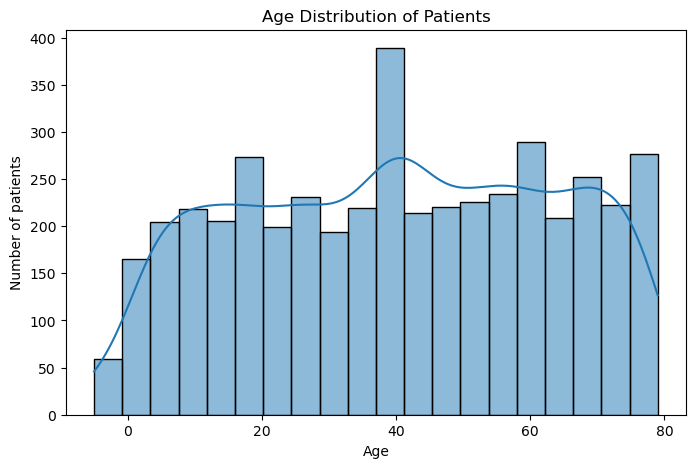

In [139]:
# Age Distribution 
plt.figure(figsize=(8,5))
sns.histplot(df["age"],bins=20,kde=True)
plt.title("Age Distribution of Patients")

plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

<h3>b.Which states appears most frequently?<h4>
    Kaduna  appears most frequently,with 299 patients. 

In [89]:
df["state"].value_counts().head()

state
Kaduna         299
Cross River    214
Gombe          213
Rivers         211
Enugu          208
Name: count, dtype: int64

<h4>c.What proportion uses mosquito nets?<h4>
    It is shown that No has the most common response with 1,927 records  

In [140]:
df["mosquito_net"].value_counts()

mosquito_net
No         1927
Yes        1923
Unknown     650
Name: count, dtype: int64

In [141]:
# Percentage
df["mosquito_net"].value_counts(normalize=True)*100

mosquito_net
No         42.822222
Yes        42.733333
Unknown    14.444444
Name: proportion, dtype: float64

<h4>d. Which season dominates?<h4>
    The rainy season dominates with 2278 records.

In [142]:
# Mosquito count
df["season"].value_counts()

season
Rainy      2278
Dry        1450
Unknown     772
Name: count, dtype: int64

In [143]:
# Percentage of mosquito count
df["season"].value_counts(normalize=True)*100

season
Rainy      50.622222
Dry        32.222222
Unknown    17.155556
Name: proportion, dtype: float64

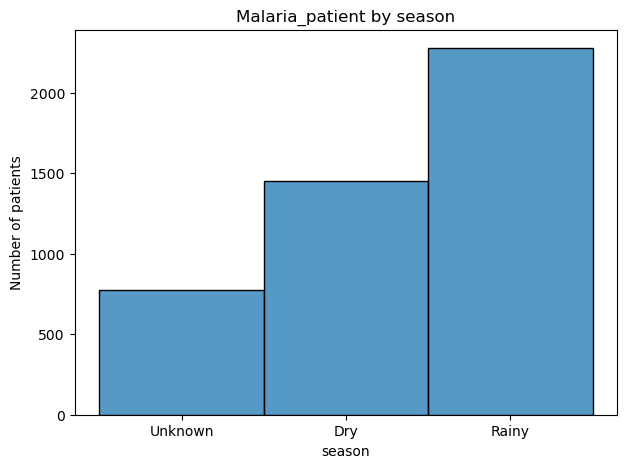

In [144]:
plt.figure(figsize=(7,5))
sns.histplot(df,x="season")
plt.title("Malaria_patient by season")
plt.xlabel("season")
plt.ylabel("Number of patients")
plt.show()

<h4>2. Bivariate Analysis<h4>
  a.Does mosquito net usage vary by state?<br><br>
     Yes,the number of responses YES and NO can be compared in each  state.<br>
     Mosquito net usage vary across state because the number of people responses are not the same in every.

In [164]:
# Net by state
pd.crosstab(df["state"],
df["mosquito_net"]).head()

mosquito_net,No,Unknown,Yes
state,,,
??Rivers,49,15,42
Abla,31,12,42
Abuja,39,7,47
Adamawa,34,13,43
Anambra,78,23,76


In [165]:
# Percentage of Net by state
pd.crosstab(df["state"],
df["mosquito_net"],normalize="index")*100

mosquito_net,No,Unknown,Yes
state,,,
??Rivers,46.226415,14.150943,39.622642
Abla,36.470588,14.117647,49.411765
Abuja,41.935484,7.526882,50.537634
Adamawa,37.777778,14.444444,47.777778
Anambra,44.067797,12.994350,42.937853
Bauchi,43.269231,15.384615,41.346154
Bayelsa,46.739130,13.043478,40.217391
Benue,40.259740,16.883117,42.857143
Borno,40.000000,6.666667,53.333333


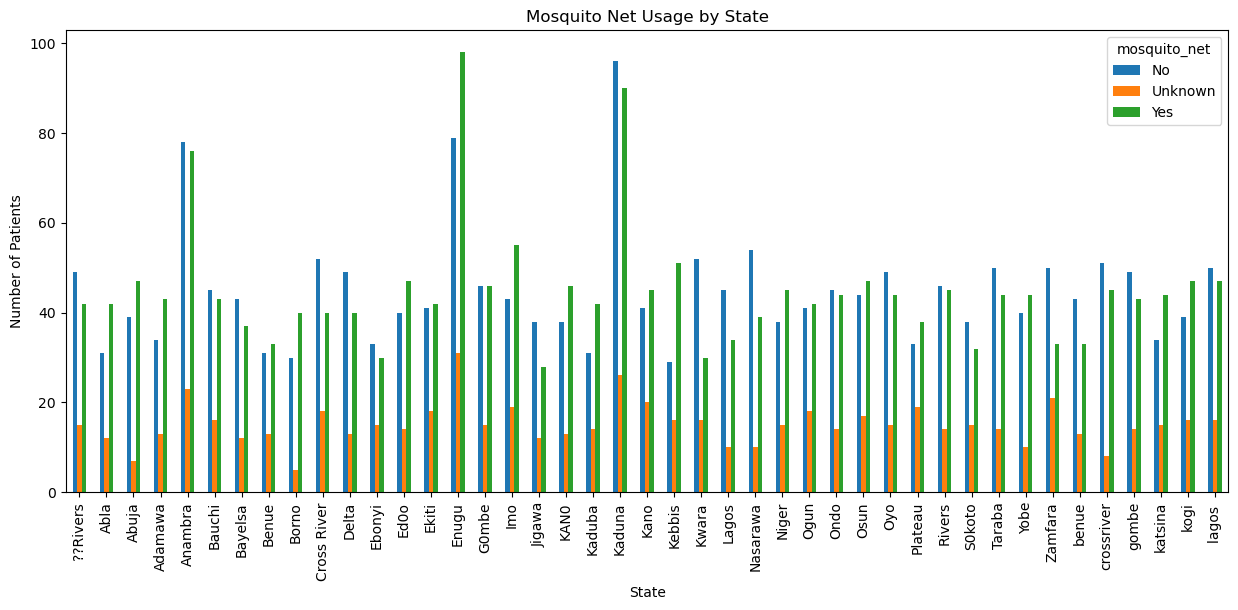

In [147]:
pd.crosstab(df["state"],
df["mosquito_net"]).plot(
    kind="bar",figsize=(15,6)
)
plt.title("Mosquito Net Usage by State")
plt.xlabel("State")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)
plt.show()

<h4>d. Does rainy periods correlate with higher cases?<h4>
         Yes

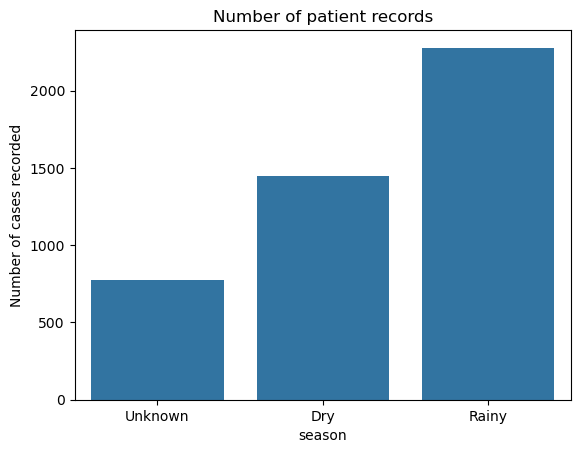

In [148]:
sns.countplot(df,x="season")
plt.title("Number of patient records")
plt.xlabel("season")
plt.ylabel("Number of cases recorded")
plt.show()

<h4>3.Multivariate Analysis(studying multiple variables together)<h4>
      a.High risk stakes durin rainy season?

In [160]:
rainy_states=(
    df[df["season"]=="Rainy"]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
)
rainy_states.head()

state
Anambra    101
Enugu       93
Kaduna      88
lagos       63
Niger       63
dtype: int64

In [157]:
age_group=pd.cut(
    pd.to_numeric(df["age"],
errors="coerce"),
    bins=[-10,18,35,50,65,100],
    labels=["0-18","19-35","36-50","51-65","66-100"]
)
pd.crosstab(
    [df["season"],df["mosquito_net"]],
    age_group.head()
)

age                   0-18  19-35  36-50  66-100
season  mosquito_net                            
Dry     Yes              0      1      0       0
Rainy   Unknown          0      0      0       1
        Yes              0      0      1       0
Unknown No               1      0      1       0

<h4>b. Combined effects of age + mosquito net + season?<h4>

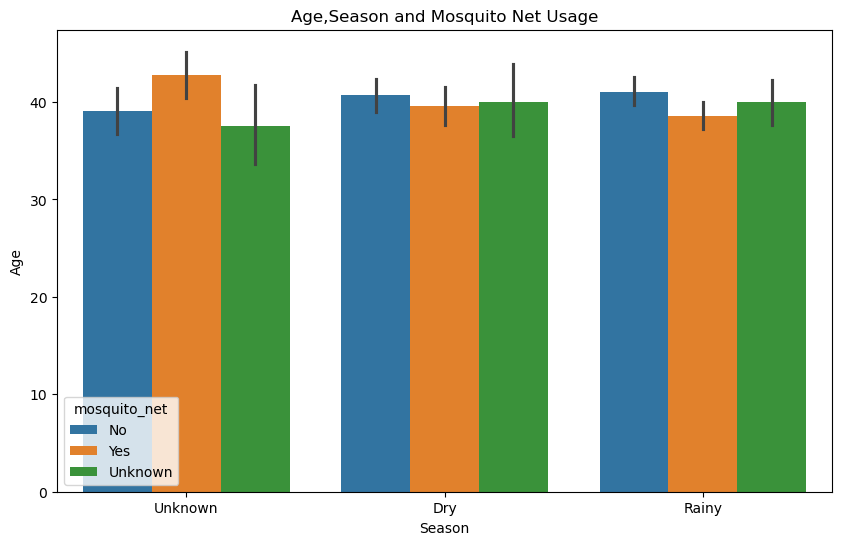

In [161]:
plt.figure(figsize=(10,6))
sns.barplot(df,x="season",y="age",hue="mosquito_net")

plt.title("Age,Season and Mosquito Net Usage")
plt.xlabel("Season")
plt.ylabel("Age")
plt.show()

<h3>Summary of what i have done<br><br>
    1. Univariate Analysis:</h3>
     a. The age distribution shows that the dataset contains patients across a wide range of ages.<br><br>
     b. Kaduna appears most frequently with 299 patients,Kaduna has the largest representation among the states.<br><br>
     c. NO has the most common response with 1927 records.<br><br>
     d. The Rainy seasons dominates in the dataset.Therefore,more patients were recorded during the rainy season than during the dry season.<br>
<h3>2. Bivariate Analysis:</h3>
     a. Mosquito net usae varies across states.The percentage table allows us to know the number of people using or not using mosquito nets in each states.<br><br>
     b. The effects of seasons on malaria positivity cannot be determined because there is no malaria positivity or test result variable in this dataset.<br><br>
     c.Younger patients being more vulnerable to malaria cannot be determined because malaria infection status variable is not included in the dataset.<br><br>
     d.Higher cases in rainy period correlate because rainy season as higher number of cases than dry season.<br>
<h3>3. Multivariate Analysis:</h3>
     a. The analysis helps to know the state that requires more attention to reduce malaria cases during rainy period.<br><br>
     b.The combined analysis shows how patient age varies across seasons and mosquito net usage groups.<br><br>
     c.The relationship between parasite count and reported cases cannot be analysed because neither parasite count nor reported cases count is included in the data set.  